In [227]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statistics
from datetime import timedelta

In [228]:
tickerSymbol_BTC = 'BTC-USD'
tickerSymbol_ETH = 'ETH-USD'
tickerSymbol_DOGE = 'DOGE-USD'

In [229]:
tickerData_BTC = yf.Ticker(tickerSymbol_BTC).history(interval='1d', start='2022-10-01', end='2024-10-01')
tickerData_ETH = yf.Ticker(tickerSymbol_ETH).history(interval='1d', start='2022-10-01', end='2024-10-01')
tickerData_DOGE = yf.Ticker(tickerSymbol_DOGE).history(interval='1d', start='2022-10-01', end='2024-10-01')

In [230]:
Data_BTC = tickerData_BTC.asfreq(pd.infer_freq(tickerData_BTC.index))
Data_ETH = tickerData_ETH.asfreq(pd.infer_freq(tickerData_ETH.index))
Data_DOGE = tickerData_DOGE.asfreq(pd.infer_freq(tickerData_DOGE.index))

In [231]:
Data_BTC = Data_BTC.reset_index()[['Close', 'Open']]
Data_ETH = Data_ETH.reset_index()[['Close', 'Open']]
Data_DOGE = Data_DOGE.reset_index()[['Close', 'Open']]

In [232]:
def SMA(close_prices: pd.Series, start_day: pd.Timestamp, end_day: pd.Timestamp) -> float:
    ema = close_prices.iloc[start_day:end_day].sum() / (end_day-start_day)
    return ema

In [233]:
def MACD(close_prices: pd.DataFrame, day: int) -> int:
    def macd_value(close_prices: pd.Series, day: int) -> int:
        # try:
        short_time_ago = day - 12 if day > 12  else 0
        short_ema = SMA(close_prices, short_time_ago, day)
        long_time_ago = day - 26 if day > 26 else 0
        long_ema = SMA(close_prices, long_time_ago, day)
        macd = short_ema - long_ema
        return macd
    macd = macd_value(close_prices.Close, day)
    if macd > 0 :
        return 1
    elif macd < 0 :
        return -1
    else:
        return 0

In [234]:
def backtest(prices: pd.Series, intial_capital: float) -> pd.Series:
    daily_equity = pd.Series([0.0 for i in prices.index],
                                index=prices.index)
    
    holding = False
    
    current_fund = intial_capital
    current_share = 0

    for index in prices.index:
        share_price = prices.iloc[index].Close
        if MACD(prices, index) == 1:
            number_of_shares = round(current_fund/share_price, 5)
            current_share += number_of_shares
            current_fund -= (number_of_shares * share_price)
        elif MACD(prices, index) == -1:
            current_fund += (current_share * share_price)
            current_share = 0
        today_price = current_fund + current_share * share_price
        daily_equity.iloc[index] = today_price
        
    return daily_equity

In [235]:
daily_equity_BTC = backtest(Data_BTC, 100)
daily_equity_ETH = backtest(Data_ETH, 100)
daily_equity_DOGE = backtest(Data_DOGE, 100)

C:\Users\Win\AppData\Local\Temp\ipykernel_25476\3291088927.py:2: RuntimeWarning: invalid value encountered in scalar divide
  ema = close_prices.iloc[start_day:end_day].sum() / (end_day-start_day)


<Axes: title={'center': 'DOGE'}, ylabel='Daily Equity'>

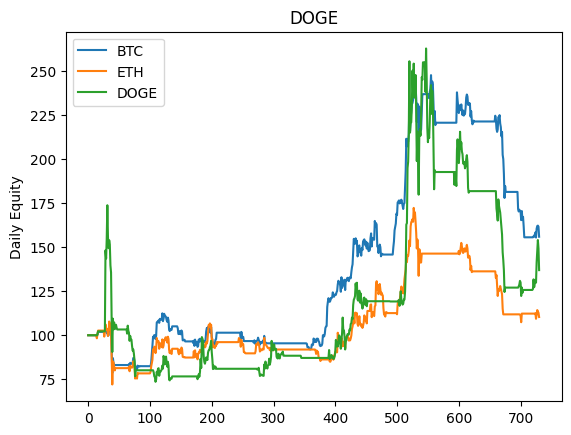

In [236]:
daily_equity_BTC.plot(label="BTC", ylabel='Daily Equity', legend=True)
daily_equity_ETH.plot(label="ETH", title="ETH", ylabel='Daily Equity', legend=True)
daily_equity_DOGE.plot(label="DOGE", title="DOGE", ylabel='Daily Equity', legend=True)

In [237]:
def Maxdrawdown(daily_equity: pd.Series, init_fund: float) -> float:
    peak = init_fund
    max_drawdown = 0
    for index in daily_equity.index:
        if daily_equity[index] < peak:
           max_drawdown = max_drawdown if daily_equity[index] - peak > max_drawdown else  daily_equity[index] - peak
        if daily_equity[index] > peak:
            peak = daily_equity[index]

    return round(100*max_drawdown/peak, 5)
        

In [238]:
def Net_Profit(daily_equity: pd.Series, init_fund: float) -> float:
    return daily_equity.iloc[-1] - init_fund 

In [240]:
max_BTC = Maxdrawdown(daily_equity_BTC, 100)
net_BTC = Net_Profit(daily_equity_BTC, 100)
max_ETH = Maxdrawdown(daily_equity_ETH, 100)
net_ETH = Net_Profit(daily_equity_ETH, 100)
max_DOGE = Maxdrawdown(daily_equity_DOGE, 100)
net_DOGE = Net_Profit(daily_equity_DOGE, 100)

In [243]:
print(f"BTC : Max Drawdown {max_BTC:.2f}, Net Profit {net_BTC:.2f}")
print(f"ETH : Max Drawdown {max_ETH:.2f}, Net Profit {net_ETH:.2f}")
print(f"DOGE : Max Drawdown {max_DOGE:.2f}, Net Profit {net_DOGE:.2f}")

BTC : Max Drawdown -37.20, Net Profit 55.85
ETH : Max Drawdown -37.63, Net Profit 10.33
DOGE : Max Drawdown -53.44, Net Profit 36.91
